# EWF + SQD Demo — Glycine (Simplest Amino Acid)

This notebook demonstrates four computational approaches for molecular quantum
calculations on **glycine** (H₂N–CH₂–COOH), the simplest amino acid. It
replicates the methodology from *"Molecular Quantum Computation on a Protein"*
at a scale that runs comfortably on a laptop — with one real QPU fragment.

| Method | Embedding | Solver(s) | QPU? |
|--------|-----------|-----------|------|
| 1 | None | Full-system CCSD | No |
| 2 | EWF | CCSD per fragment | No |
| 3 | EWF | FCI (small frags) + **SQD** (C=O fragment) | **Yes** |
| 4 | EWF | FCI (small frags) + **TrimSQD** (C=O fragment) | Yes (reused) |

Methods 3 and 4 use the **same QPU job** — TrimSQD re-uses the `counts.npy`
checkpoint and applies a screening-based classical post-processing policy
that typically recovers lower energies with the same shot budget.

### Why glycine?
Glycine has 5 heavy atoms (N, Cα, C=O, O×2). IAO fragmentation with an MP2
bath at `truncation=1e-4` produces 10 fragments. The C=O carbonyl fragment
grows to 19 cluster orbitals — above the classical threshold — making it the
natural candidate for SQD. All other fragments run as FCI or CCSD in seconds.

### Fragment map (STO-3G, three-tier adaptive)
```
Frag 2  C=O fragment  19 orb  → SQD / TrimSQD on ibm_kingston  (38 qubits)
Frag 1  Cα-fragment  ~17 orb  → CCSD
Frag 0  N-fragment   ~13 orb  → CCSD
Frag 3  O-fragment   ~13 orb  → CCSD
Frag 4  O-fragment   ~13 orb  → CCSD
Frags 5–9  H ×5       3–4 orb → FCI
```


---
## Environment Setup

**Run the cell below once per new Python environment before anything else.**
It is safe to re-run — pip skips packages that are already up to date.

### Prerequisites

| Requirement | Notes |
|---|---|
| **Python 3.12** | 3.11 also works; 3.13+ is not yet supported by `ffsim` / `vayesta` |
| **Xcode Command Line Tools** | Required to build Vayesta's C extension. Install with `xcode-select --install` |
| **CMake** | Required to build Vayesta. Install with `brew install cmake` |
| **Git** | Required to clone Vayesta from GitHub. Usually pre-installed on macOS |

### Kernel selection (VS Code / JupyterLab)

Make sure this notebook is running on a **Python 3.12 kernel**, not the system
Python or a 3.14 kernel. In VS Code, click the kernel name in the top-right
corner and choose a 3.12 interpreter. To create one from scratch:

```zsh
# In your terminal — run once
python3.12 -m venv .venv312
.venv312/bin/pip install ipykernel
.venv312/bin/python -m ipykernel install --user --name qfm-3.12 --display-name "Python 3.12 (QFM)"
```

Then reload VS Code and select **Python 3.12 (QFM)** as the kernel.

### Vayesta — special install note

Vayesta is not published to PyPI and must be built from source. Its `setup.py`
has a macOS build bug (`clang: error: no input files`) that requires a one-line
patch before installing. **The install cell below handles this automatically.**
If you are on Linux, the patch is harmless.

In [1]:
# ---------------------------------------------------------------------------
# Dependency installer — run once per new environment, then restart the kernel
# ---------------------------------------------------------------------------
import subprocess, sys, shutil, os, tempfile
from pathlib import Path

_nb_dir   = Path().resolve()         # directory where the kernel was launched
_pkg_root = _nb_dir.parents[2]       # ewf_sqd_demo → notebook_demos → examples → repo root

def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *args])

def _run(*cmd):
    subprocess.check_call(list(cmd))

# 1. Standard PyPI packages (no Rust build required)
print("Installing PyPI dependencies...")
_pip(
    "pyscf>=2.9.0",
    "matplotlib",
    "numpy>=1.24.0",
    "pyyaml",
    "pandas",
    "qiskit>=1.0.0",
    "qiskit-ibm-runtime>=0.15.0",
    "qiskit-addon-sqd>=0.12.0",
    "ffsim>=0.0.1",
    "h5py",
    "python-dotenv",
)
print("  PyPI dependencies OK")

# 2. qrmi[ibm] — Rust extension, no macOS pre-built wheel; must compile from source.
#    Requires Rust >= 1.88. rustup is the safest way to get a current toolchain
#    because Homebrew's rustc lags behind.
print("\nChecking Rust toolchain for qrmi build...")
_rustup = shutil.which("rustup") or os.path.expanduser("~/.cargo/bin/rustup")
_cargo  = shutil.which("cargo")  or os.path.expanduser("~/.cargo/bin/cargo")

if not os.path.exists(_rustup):
    raise RuntimeError(
        "rustup not found. Install it first:\n"
        "  curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh\n"
        "Then open a new terminal and re-run this cell."
    )

# Update to latest stable — harmless if already current, fixes 1.85→1.88 gap
print("  Updating Rust stable toolchain (rustup update)...")
_run(_rustup, "update", "stable", "--no-self-update")

# Put rustup-managed cargo on PATH for the maturin build
_cargo_home = Path(_rustup).parent
os.environ["PATH"] = str(_cargo_home) + os.pathsep + os.environ.get("PATH", "")
print(f"  Rust OK — cargo: {_cargo_home / 'cargo'}")

print("  Building qrmi[ibm] from source (this takes 2–5 min)...")
_pip("qrmi[ibm]")
print("  qrmi[ibm] OK")

# 3. Vayesta — not on PyPI; must be built from GitHub source.
#    Vayesta's setup.py calls super().run() after its CMakeBuild, which fires
#    clang with sources=[] and fails on macOS. We clone, patch that one line,
#    then install from the patched local copy.
_vayesta_src = Path(tempfile.mkdtemp()) / "Vayesta"
print("\nCloning Vayesta from GitHub (this takes ~30 s)...")
_run("git", "clone", "--depth=1", "--quiet",
     "https://github.com/BoothGroup/Vayesta.git", str(_vayesta_src))

# Patch: comment out the super().run() that fires clang with no sources
_setup_py = _vayesta_src / "setup.py"
_setup_py.write_text(
    _setup_py.read_text().replace(
        "        super().run()",
        "        # super().run()  # patched: CMakeExtension has sources=[] → clang error on macOS",
        1,
    )
)
print("  setup.py patched")
print("  Building and installing Vayesta (this takes 1–3 min)...")
_pip("--no-build-isolation", str(_vayesta_src))
shutil.rmtree(str(_vayesta_src.parent), ignore_errors=True)
print("  Vayesta OK")

# 4. Local quantum-fragment-methods package (editable install)
print("\nInstalling quantum-fragment-methods from", _pkg_root, "...")
_pip("-e", str(_pkg_root))
print("  quantum-fragment-methods OK")

print("\n✓ All dependencies installed. Restart the kernel, then run the notebook.")

Installing PyPI dependencies...
  PyPI dependencies OK

Checking Rust toolchain for qrmi build...
  Updating Rust stable toolchain (rustup update)...


info: syncing channel updates for stable-aarch64-apple-darwin



  stable-aarch64-apple-darwin unchanged - rustc 1.98.1 (48a229cea 2026-09-01)

  Rust OK — cargo: /Users/thaddeuspellegrini/.cargo/bin/cargo
  Building qrmi[ibm] from source (this takes 2–5 min)...
  qrmi[ibm] OK

Cloning Vayesta from GitHub (this takes ~30 s)...
  setup.py patched
  Building and installing Vayesta (this takes 1–3 min)...
Processing /var/folders/h5/vk4dp3hj3hl5h63968_bg6c00000gn/T/tmpmvks2bef/Vayesta
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/pyscf/pyscf (to revision master) to /private/var/folders/h5/vk4dp3hj3hl5h63968_bg6c00000gn/T/pip-install-svg_p7m7/pyscf_be4d04984724448196e367d542aac49f


  Running command git clone --filter=blob:none --quiet https://github.com/pyscf/pyscf /private/var/folders/h5/vk4dp3hj3hl5h63968_bg6c00000gn/T/pip-install-svg_p7m7/pyscf_be4d04984724448196e367d542aac49f


  Resolved https://github.com/pyscf/pyscf to commit 9f1d317a1ad8374798461911ec646184d1e5bdf2
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for Vayesta: filename=vayesta-1.0.1-cp312-cp312-macosx_26_0_arm64.whl size=683371 sha256=c402b74a14b4612f3141432ad0d7e1bad5f5e29fbfe38165955348bc3dfe4235
  Stored in directory: /private/var/folders/h5/vk4dp3hj3hl5h63968_bg6c00000gn/T/pip-ephem-wheel-cache-iopryyfr/wheels/86/ce/fa/311450db0adfea1cf4690306890a068a1ebd987e3545cfc082
Successfully built Vayesta
  Attempting uninstall: Vayesta
    Found existing installation: Vayesta 1.0.1
    Uninstalling Vayesta-1.0.1:
      Successfully uninstalled Vayesta-1.0.1
  Vayesta OK

Installing quantum-fragment-methods from /Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods ...
Obtaining file:///Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods


---
## 0 — Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyscf
import yaml
from pyscf import cc, scf

from quantum_fragment_methods.application.embedding import EWF
from quantum_fragment_methods.application.solvers.classical_zoo import CCSD, FCI
from quantum_fragment_methods.application.solvers.quantum_zoo.sqd import SQDSolver
from quantum_fragment_methods.application.solvers.quantum_zoo.trim_sqd import TrimSQDSolver
from quantum_fragment_methods.workflow import QFWorkflow

In [3]:
# ---------------------------------------------------------------------------
# Paths — resolved relative to this notebook so the demo works whether the
# repo is mounted at /workspace or checked out locally.
# ---------------------------------------------------------------------------
DEMO_DIR = Path().resolve()          # kernel CWD = notebook directory
XYZ_FILE = DEMO_DIR / "system_glycine.xyz"
CONFIG_FILE = DEMO_DIR / "config_glycine_sto-3g.yaml"

# Read geometry (skip the 2-line XYZ header)
xyz_lines = XYZ_FILE.read_text().splitlines()
geometry_data = "\n".join(xyz_lines[2:])

print(f"Molecule : {xyz_lines[1]}")
print(f"Atoms    : {xyz_lines[0].strip()}")
print(f"Config   : {CONFIG_FILE}")

Molecule : Glycine (H2N-CH2-COOH) — optimised geometry (PubChem CID 750)
Atoms    : 10
Config   : /Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods/examples/notebook_demos/ewf_sqd_demo/config_glycine_sto-3g.yaml


In [4]:
# Load config — all tunable parameters live here
with open(CONFIG_FILE) as f:
    config = yaml.safe_load(f)

qpu_config      = config["qpu"]
sqd_config      = config["sqd"]
embedder_config = config["embedder"]["ewf"]
sel_config      = config["solver_selection"]
fci_threshold  = sel_config["fci_threshold"]
ccsd_threshold = sel_config["ccsd_threshold"]
sqd_threshold  = sel_config["sqd_threshold"]
sampler_opts    = qpu_config.get("sampler_options", {})

print(f"Basis            : {config['workflow']['basis']}")
print(f"Bath type        : {embedder_config['bath_type']}")
print(f"Truncation       : {embedder_config['truncation']}")
print(f"FCI  threshold   : n_orb ≤ {fci_threshold}")
print(f"CCSD threshold   : {fci_threshold} < n_orb < {sqd_threshold}")
print(f"SQD  threshold   : n_orb ≥ {sqd_threshold}  (ibm_kingston)")
print(f"QPU backend      : {qpu_config['backend_name']}")
print(f"Shots            : {sampler_opts.get('default_shots', 10000)}")
dd = sampler_opts.get('dynamical_decoupling', {})
print(f"DD enabled       : {dd.get('enable', False)}  (sequence: {dd.get('sequence_type', 'n/a')})")


Basis            : sto-3g
Bath type        : mp2
Truncation       : 0.0001
FCI  threshold   : n_orb ≤ 10
CCSD threshold   : 10 < n_orb < 19
SQD  threshold   : n_orb ≥ 19  (ibm_kingston)
QPU backend      : ibm_kingston
Shots            : 100000
DD enabled       : True  (sequence: XY4)


---
## Method 1 — Full-system CCSD (reference)

Single coupled-cluster calculation on the entire glycine molecule, no
fragmentation. Serves as the accuracy benchmark.

- 10 atoms, STO-3G → 28 basis functions
- Wall time: ~5 s on a laptop

In [5]:
mol = pyscf.gto.Mole()
mol.atom   = geometry_data
mol.unit   = "Angstrom"
mol.basis  = config["workflow"]["basis"]
mol.verbose = 3
mol.build()

In [6]:
mf = scf.RHF(mol)
mf.kernel()
hf_energy = mf.e_tot
print(f"HF energy: {hf_energy:.8f} Ha")

converged SCF energy = -278.905788665211
HF energy: -278.90578867 Ha


In [7]:
mycc = cc.CCSD(mf)
mycc.kernel()
energy_full_ccsd = mycc.e_tot

print(f"\n{'='*55}")
print(f"Method 1: Full-system CCSD")
print(f"{'='*55}")
print(f"HF energy      : {hf_energy:.8f} Ha")
print(f"CCSD energy    : {energy_full_ccsd:.8f} Ha")
print(f"Correlation    : {(energy_full_ccsd - hf_energy)*1000:.4f} mHa")
print(f"{'='*55}")

E(CCSD) = -279.2162392572901  E_corr = -0.3104505920787068

Method 1: Full-system CCSD
HF energy      : -278.90578867 Ha
CCSD energy    : -279.21623926 Ha
Correlation    : -310.4506 mHa


---
## Method 2 — EWF + CCSD (fragmented, all classical)

The Embedded Wave Function (EWF) method partitions glycine into IAO fragments,
adds an MP2 bath to each, then solves each fragment independently with CCSD.
This is the classical baseline for the hybrid method below.

- Fragmentation: IAO (one fragment per heavy atom + H pseudo-fragments)
- Bath: MP2, `truncation=1e-4`
- Solver: CCSD for all fragments
- Wall time: ~30–60 s on a laptop

In [8]:
ewf_ccsd = EWF(
    bath_type  = embedder_config["bath_type"],
    truncation = embedder_config["truncation"],
)

workflow_ccsd = QFWorkflow(
    geometry      = geometry_data,
    basis         = config["workflow"]["basis"],
    embedder      = ewf_ccsd,
    fragmentation = embedder_config["fragmentation"],
    save_path     = str(DEMO_DIR / "results_ewf_ccsd"),
)

workflow_ccsd.add_solver_rule(
    solver_factory = lambda frag: CCSD(),
    condition      = None,
    priority       = 0,
)

In [ ]:
print("Running EWF+CCSD...")
results_ewf_ccsd = workflow_ccsd.run()
energy_ewf_ccsd  = results_ewf_ccsd.total_energy

print(f"\n{'='*55}")
print(f"Method 2: EWF + CCSD")
print(f"{'='*55}")
print(f"Fragments      : {len(results_ewf_ccsd.fragment_energies)}")
print(f"Total energy   : {energy_ewf_ccsd:.8f} Ha")
print(f"Δ from CCSD ref: {(energy_ewf_ccsd - energy_full_ccsd)*1000:.4f} mHa")
print(f"{'='*55}")

Running EWF+CCSD...
converged SCF energy = -278.9062276439
Mean-Field (Hartree-Fock) energy = -278.90622764390014 Ha


          |
          |  INITIALIZING EWF
          |  ================
          |      Initial E(mean-field)=    -278.90622764 Ha
          |      Calculated E(HF)=         -278.90622764 Ha
          |      Difference dE=              +0.00000000 Ha ( -0.0%)
          |      n(AO)=   30  n(MO)=   30  n(linear dep.)=    0
          |      Parameters of EWF:
          |      Options(store_eris=True, global_frag_chempot=None, dm_with_frozen=False, bath_options={'bathtype':
          |          'mp2', 'canonicalize': True, 'occupation_tolerance': 1e-06, 'dmet_threshold': 1e-08, 'rcut': None,
          |          'unit': 'Ang', 'order': None, 'max_order': 20, 'threshold': 0.0001, 'truncation': 'occupation',
          |          'project_dmet_order': 2, 'project_dmet_mode': 'squared-entropy', 'addbuffer': False, 'bathtype_occ':
          |          None, 'bathtype_vir': None, 'rcut_occ': None, 'rcut_vir': None, 'unit_occ': None, 'unit_vir': None,
          |          'order_occ': None, 'or

No module named 'dyson'
Dyson required for self-energy calculations


          |          Entanglement entropy: total= 2.402e-01  bath= 2.402e-01 (100.00 %)
          |          Cluster orbitals:  n(occ)=   1  n(vir)=   1
          |      Making Occupied BNOs
          |      --------------------
          |          Projecting DMET space for MP2 bath (mode= squared-entropy, order= 2).
          |          Occupied BNO histogram:
          |                                                   ___
          |                                                  |:::|
          |                                                  |:::|
          |                                         ___  ___ |:::|
          |                     ___       ___      |:::||:::||:::|
          |                ___ |:::| ___ |:::| ___ |:::||:::||:::|
          |          +-------------------------------------------+
          |              E-3  E-4  E-5  E-6  E-7  E-8  E-9  E-10
          |      Making Virtual BNOs
          |      -------------------
          |          Project

          |  Clusters dumped to file '/Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods/examples/notebook_demos/ewf_sqd_demo/results_ewf_ccsd/vayesta_dump.h5'


Overwritten attributes  get_hcore get_ovlp  of <class 'pyscf.scf.hf.RHF'>


Solving fragment 0 with CCSD...
converged SCF energy = -96.2950966414956
  Fragment 0 correlation energy: -0.09500800 Ha
Solving fragment 1 with CCSD...
converged SCF energy = -89.4878289444959
  Fragment 1 correlation energy: -0.11965295 Ha
Solving fragment 2 with CCSD...
converged SCF energy = -142.800882649129
  Fragment 2 correlation energy: -0.20606883 Ha
Solving fragment 3 with CCSD...
converged SCF energy = -110.218806928813
  Fragment 3 correlation energy: -0.12730908 Ha
Solving fragment 4 with CCSD...
converged SCF energy = -109.370208322676
  Fragment 4 correlation energy: -0.12957824 Ha
Solving fragment 5 with CCSD...
converged SCF energy = -7.68463272182046
  Fragment 5 correlation energy: -0.01691770 Ha
Solving fragment 6 with CCSD...
converged SCF energy = -7.64532334469819
  Fragment 6 correlation energy: -0.01684391 Ha
Solving fragment 7 with CCSD...
converged SCF energy = -7.6453233446982
  Fragment 7 correlation energy: -0.01684391 Ha
Solving fragment 8 with CCSD...
c

---
## Method 3 — EWF + FCI/SQD (adaptive, hybrid quantum)

Same EWF fragmentation, but now with **adaptive solver selection**:

| Rule | Condition | Solver |
|------|-----------|--------|
| Priority 20 | `n_orbitals < 11` | FCI (exact, fast) |
| Priority 10 | `12 =< n_orbitals < 19` | CCSD (approx., fast) |
| Priority 0  | `n_orbitals ≥ 19` | SQD on **ibm_kingston** |

The C=O carbonyl fragment (19 orbitals) is the only one that exceeds the
threshold. Its 38-qubit LUCJ circuit is submitted to `ibm_kingston`.

**QPU workflow (checkpoint-aware):**
1. Running this cell submits the QPU job and prints a job ID.
2. The job ID is saved to `results_ewf_adaptive/fragment_0/job_id.txt`.
3. Re-running after the job completes automatically resumes — no resubmission.
4. To force a fresh QPU submission: delete `job_id.txt` and `counts.npy`
   from that directory.


### 3a — Credentials

This notebook uses **QRMI** (Quantum Resource Management Interface) to access
IBM Quantum hardware. QRMI reads credentials from **environment variables**,
never from config files — so your token never touches the notebook or git.

**Setup (one time per environment):**

1. Copy the example env file to `.env` in this directory:
   ```zsh
   cp examples/notebook_demos/ewf_sqd_demo/.env.example \
      examples/notebook_demos/ewf_sqd_demo/.env
   ```
2. Open `.env` and fill in your IBM Quantum credentials:
   ```
   ibm_kingston_QRMI_IBM_QCS_IAM_APIKEY=<your-iam-api-key>
   ibm_kingston_QRMI_IBM_QCS_SERVICE_CRN=<your-crn>
   ```
   The prefix (`ibm_kingston_`) must be **lowercase** and match `QRMI_JOB_QPU_RESOURCES` exactly.
   Your IAM API key and CRN are available at [quantum.ibm.com](https://quantum.ibm.com/account).

The `.env` file is gitignored — it will never be committed.

> **HPC / Slurm:** When running on SCC, skip the `.env` file entirely.
> The Slurm SPANK plugin injects all `QRMI_*` environment variables
> automatically when your job requests `--gres=qpu:1 --qpu=ibm_kingston`.

In [10]:
import os
from dotenv import load_dotenv
from quantum_fragment_methods.qpu.qrmi import QRMIBackend

# Load .env without overriding variables already set by Slurm SPANK plugin
load_dotenv(DEMO_DIR / ".env", override=False)

# Fall back to ibm_kingston for interactive use if Slurm hasn't set the resource
BACKEND_NAME = os.environ.get("QRMI_JOB_QPU_RESOURCES", "ibm_kingston")
os.environ.setdefault("QRMI_JOB_QPU_RESOURCES", BACKEND_NAME)
os.environ.setdefault("QRMI_JOB_QPU_TYPES", "ibm-quantum-compute-service")

# Initialize QRMI backend — credentials come from env vars, not from config
backend = QRMIBackend({"backend_name": BACKEND_NAME})
backend.initialize()
backend.get_backend()

props = backend.get_backend_properties()
print(f"Backend  : {props['backend_name']}")
print(f"Type     : {props['resource_type']}")
print(f"Env var  : QRMI_JOB_QPU_RESOURCES={BACKEND_NAME}")

Backend  : ibm_kingston
Type     : ResourceType.IBMQuantumComputeService
Env var  : QRMI_JOB_QPU_RESOURCES=ibm_kingston


### 3b — Build workflow and solve

In [11]:
ewf_adaptive = EWF(
    bath_type  = embedder_config["bath_type"],
    truncation = embedder_config["truncation"],
)

workflow_adaptive = QFWorkflow(
    geometry      = geometry_data,
    basis         = config["workflow"]["basis"],
    embedder      = ewf_adaptive,
    fragmentation = embedder_config["fragmentation"],
    save_path     = str(DEMO_DIR / "results_ewf_adaptive"),
)

fci_threshold  = sel_config['fci_threshold']   # n_orb <= this → FCI
ccsd_threshold = sel_config['ccsd_threshold']  # fci_threshold < n_orb <= this → CCSD
sqd_threshold  = sel_config['sqd_threshold']   # n_orb >= this → SQD

# Rule 1 (priority 20): FCI for H fragments (≤ fci_threshold orbitals)
workflow_adaptive.add_solver_rule(
    solver_factory = lambda frag: FCI(),
    condition      = lambda frag: frag.n_orbitals <= fci_threshold,
    priority       = 20,
)

# Rule 2 (priority 10): CCSD for medium fragments (fci_threshold < n_orb < sqd_threshold)
workflow_adaptive.add_solver_rule(
    solver_factory = lambda frag: CCSD(),
    condition      = lambda frag: fci_threshold < frag.n_orbitals < sqd_threshold,
    priority       = 10,
)

# Rule 3 (priority 0): SQD for the largest fragment (≥ sqd_threshold orbitals)
# workflow_path is set per-fragment inside solve() so each fragment
# keeps its own job_id.txt / counts.npy checkpoint.
workflow_adaptive.add_solver_rule(
    solver_factory = lambda frag: SQDSolver(backend, config=sqd_config),
    condition      = None,
    priority       = 0,
)


In [12]:
# Show actual cluster sizes from the EWF+CCSD run (same bath → same cluster sizes)
# This tells us whether sqd_threshold correctly isolates the C=O fragment.
print("Fragment cluster sizes (from EWF+CCSD run):")
for fid, frag in enumerate(results_ewf_ccsd.fragments):
    n_frag = frag.metadata.get("n_frag_orbitals", "?")
    fci_t, sqd_t = sel_config["fci_threshold"], sel_config["sqd_threshold"]
    solver_name = "SQD" if frag.n_orbitals >= sqd_t else ("FCI" if frag.n_orbitals <= fci_t else "CCSD")
    print(f"  Fragment {fid:2d}: cluster_norb={frag.n_orbitals:3d}  frag_nao={n_frag}  → {solver_name}")
print()
print("SQD parameters:")
print(f"  default_shots    : {qpu_config['sampler_options']['default_shots']}")
print(f"  iterations       : {sqd_config['iterations']}")
print(f"  n_batches        : {sqd_config['n_batches']}")
print(f"  samples_per_batch: {sqd_config['samples_per_batch']}")
print(f"  classical_backend: {sqd_config['classical_backend']}")


Fragment cluster sizes (from EWF+CCSD run):
  Fragment  0: cluster_norb= 13  frag_nao=0  → CCSD
  Fragment  1: cluster_norb= 17  frag_nao=0  → CCSD
  Fragment  2: cluster_norb= 19  frag_nao=0  → SQD
  Fragment  3: cluster_norb= 13  frag_nao=0  → CCSD
  Fragment  4: cluster_norb= 13  frag_nao=0  → CCSD
  Fragment  5: cluster_norb=  3  frag_nao=0  → FCI
  Fragment  6: cluster_norb=  3  frag_nao=0  → FCI
  Fragment  7: cluster_norb=  3  frag_nao=0  → FCI
  Fragment  8: cluster_norb=  4  frag_nao=0  → FCI
  Fragment  9: cluster_norb=  4  frag_nao=0  → FCI

SQD parameters:
  default_shots    : 100000
  iterations       : 6
  n_batches        : 6
  samples_per_batch: 3000
  classical_backend: python


In [13]:
# Run. The QPU job is submitted synchronously; `--wait` polls until complete.
# If the job is still queued when the kernel times out, just re-run this
# cell — it will resume from the saved checkpoint automatically.
print("Running EWF + FCI/SQD ...")
print("=" * 55)
results_ewf_adaptive = workflow_adaptive.run()
energy_ewf_adaptive  = results_ewf_adaptive.total_energy

Running EWF + FCI/SQD ...
converged SCF energy = -278.9062276439


          |
          |  INITIALIZING EWF
          |  ================
          |      Initial E(mean-field)=    -278.90622764 Ha
          |      Calculated E(HF)=         -278.90622764 Ha
          |      Difference dE=              +0.00000000 Ha ( -0.0%)
          |      n(AO)=   30  n(MO)=   30  n(linear dep.)=    0
          |      Parameters of EWF:
          |      Options(store_eris=True, global_frag_chempot=None, dm_with_frozen=False, bath_options={'bathtype':
          |          'mp2', 'canonicalize': True, 'occupation_tolerance': 1e-06, 'dmet_threshold': 1e-08, 'rcut': None,
          |          'unit': 'Ang', 'order': None, 'max_order': 20, 'threshold': 0.0001, 'truncation': 'occupation',
          |          'project_dmet_order': 2, 'project_dmet_mode': 'squared-entropy', 'addbuffer': False, 'bathtype_occ':
          |          None, 'bathtype_vir': None, 'rcut_occ': None, 'rcut_vir': None, 'unit_occ': None, 'unit_vir': None,
          |          'order_occ': None, 'or

Mean-Field (Hartree-Fock) energy = -278.90622764390014 Ha


          |          Cluster orbitals:  n(occ)=   5  n(vir)=   5
          |      Making Occupied BNOs
          |      --------------------
          |          Projecting DMET space for MP2 bath (mode= squared-entropy, order= 2).
          |          Occupied BNO histogram:
          |           ___
          |          |:::|
          |          |:::|           ___
          |          |:::|          |:::|
          |          |:::| ___      |:::|      ___
          |          |:::||:::| ___ |:::| ___ |:::|      ___
          |          +-------------------------------------------+
          |              E-3  E-4  E-5  E-6  E-7  E-8  E-9  E-10
          |      Making Virtual BNOs
          |      -------------------
          |          Projecting DMET space for MP2 bath (mode= squared-entropy, order= 2).
          |          Virtual BNO histogram:
          |                ___
          |               |:::|
          |               |:::|
          |               |:::|      __

          |  Clusters dumped to file '/Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods/examples/notebook_demos/ewf_sqd_demo/results_ewf_adaptive/vayesta_dump.h5'
Solving fragment 0 with CCSD...
converged SCF energy = -96.2950966414956
  Fragment 0 correlation energy: -0.09500800 Ha
Solving fragment 1 with CCSD...
converged SCF energy = -89.4878289444959
  Fragment 1 correlation energy: -0.11965295 Ha
Solving fragment 2 with SQD...
  QPU job submitted: dak0nsgmhr3c73e9ibhg
  Backend: ibm_kingston  checkpoint: /Users/thaddeuspellegrini/Code/QuantumAlgorithmEngineering/QDC_2026/quantum-fragment-methods/examples/notebook_demos/ewf_sqd_demo/results_ewf_adaptive/fragment_2/job_id.txt
  Polling job dak0nsgmhr3c73e9ibhg every 30s (max 86400s) ...
  00s] dak0nsgmhr3c73e9ibhg — QUEUED
  30s] dak0nsgmhr3c73e9ibhg — QUEUED
  00s] dak0nsgmhr3c73e9ibhg — QUEUED
  31s] dak0nsgmhr3c73e9ibhg — QUEUED
  01s] dak0nsgmhr3c73e9ibhg — QUEUED
  31s] dak0nsgmhr3c73e

In [14]:
fci_count  = sum(1 for frag in results_ewf_adaptive.fragments
                 if frag.n_orbitals <= fci_threshold)
ccsd_count = sum(1 for frag in results_ewf_adaptive.fragments
                 if fci_threshold < frag.n_orbitals < sqd_threshold)
sqd_count  = sum(1 for frag in results_ewf_adaptive.fragments
                 if frag.n_orbitals >= sqd_threshold)

print(f"\n{'='*55}")
print(f"Method 3: EWF + FCI/SQD — COMPLETED")
print(f"{'='*55}")
print(f"Fragments        : {len(results_ewf_adaptive.fragment_energies)}")
print(f"  FCI fragments  : {fci_count}")
print(f"  SQD fragments  : {sqd_count}  (ibm_kingston)")
print(f"Total energy     : {energy_ewf_adaptive:.8f} Ha")
print(f"Δ from CCSD ref  : {(energy_ewf_adaptive - energy_full_ccsd)*1000:.4f} mHa")
print(f"{'='*55}")



Method 3: EWF + FCI/SQD — COMPLETED
Fragments        : 10
  FCI fragments  : 5
  SQD fragments  : 1  (ibm_kingston)
Total energy     : -279.26684187 Ha
Δ from CCSD ref  : -50.6026 mHa


In [15]:
# ── CCSD reference on fragment 2 — classical benchmark for SQD ───────────────
# The EWF+CCSD run (Method 2) already solved every fragment with CCSD.
# We pull fragment 2's result directly — no extra computation needed.
_e_casci = results_ewf_ccsd.fragment_results[2].energy

print(f'Fragment 2 CCSD reference : {_e_casci:.8f} Ha')

Fragment 2 CCSD reference : -143.00695148 Ha


---
## Method 4 — EWF + FCI/TrimSQD

Same workflow as Method 3 — **no additional QPU job**.  TrimSQD re-uses the
`counts.npy` checkpoint saved for fragment 2 (C=O) and applies a different
classical post-processing policy:

| | Standard SQD | TrimSQD |
|--|-------------|--------|
| Batches | independent subsamples | one disjoint pool, partitioned |
| Screening | — | diagonalize each batch, trim top-weight CI strings |
| Reporting | best-batch energy | merged-subspace diagonalization |

TrimSQD trades one extra FCI call per iteration for broader subspace coverage.

**This section also computes a CASCI (FCI) reference** on the same fragment 2
cluster Hamiltonian — the exact ground-state energy for that subspace — so we
can benchmark SQD and TrimSQD against it directly.


In [16]:
import h5py as _h5py
from pathlib import Path as _Path
import numpy as _np

# ── Load fragment 2 counts from existing checkpoint ──────────────────────────
_ckpt = DEMO_DIR / 'results_ewf_adaptive' / 'fragment_2' / 'counts.npy'
_counts_raw = _np.load(_ckpt, allow_pickle=True).item()

# ── Load fragment 2 Hamiltonian from the EWF dumpfile ────────────────────────
_persistent_dump2 = DEMO_DIR / 'results_ewf_adaptive' / 'vayesta_dump.h5'
_dumpfile = (
    str(_persistent_dump2)
    if _persistent_dump2.exists()
    else results_ewf_adaptive.embedding_result.metadata.get('dumpfile')
)
with _h5py.File(_dumpfile, 'r') as _f:
    _fg = _f['fragment_2']
    _h1e_trim = _fg['heff'][:]
    _h2e_trim = _fg['eris'][:]
    _norb_trim = int(_fg.attrs['norb'])
    _nocc_trim = int(_fg.attrs['nocc'])

_nelec_trim = (_nocc_trim, _nocc_trim)

# ── Run TrimSQD post-processing ───────────────────────────────────────────────
trim_solver = TrimSQDSolver(backend, config=sqd_config)
result_trim_frag2 = trim_solver._sbd_postprocessing(
    h1e=_h1e_trim,
    h2e=_h2e_trim,
    counts=_counts_raw,
    norb=_norb_trim,
    nelec=_nelec_trim,
    workflow_path=DEMO_DIR / 'results_ewf_adaptive' / 'fragment_2',
)

trim_e: float = result_trim_frag2.energy

std_e  = results_ewf_adaptive.fragment_results[2].energy
fci_e  = _e_casci  # CCSD reference from cell above

print(f'Fragment 2 energies (embedded cluster, {_norb_trim} orb):')
print(f'  CCSD reference         : {fci_e:.8f} Ha')
print(f'  Standard SQD           : {std_e:.8f} Ha   ({(std_e - fci_e)*1000:+.4f} mHa vs CCSD)')
print(f'  TrimSQD                : {trim_e:.8f} Ha   ({(trim_e - fci_e)*1000:+.4f} mHa vs CCSD)')
print(f'  TrimSQD improvement    : {(std_e - trim_e)*1000:+.4f} mHa')

  TrimSQD: 6 iter × 6 batches × 3000 samples  trim_ratio=0.15  TrimPolicy  backend=python
Fragment 2 energies (embedded cluster, 19 orb):
  CCSD reference         : -143.00695148 Ha
  Standard SQD           : -143.00251279 Ha   (+4.4387 mHa vs CCSD)
  TrimSQD                : -142.97713201 Ha   (+29.8195 mHa vs CCSD)
  TrimSQD improvement    : -25.3808 mHa


In [17]:
# ── Reconstruct total EWF+TrimSQD energy ─────────────────────────────────────
# Total energy = EWF+SQD total + (TrimSQD frag2 - SQD frag2)
energy_ewf_trimsqd = (results_ewf_adaptive.total_energy
                      + result_trim_frag2.energy
                      - results_ewf_adaptive.fragment_results[2].energy)

print(f"\n{'='*65}")
print(f'Method 4: EWF + FCI/TrimSQD — COMPLETED')
print(f"{'='*65}")
print(f'Total energy     : {energy_ewf_trimsqd:.8f} Ha')
print(f'Δ from CCSD ref  : {(energy_ewf_trimsqd - energy_full_ccsd)*1000:.4f} mHa')
print(f'TrimSQD vs SQD   : {(energy_ewf_trimsqd - energy_ewf_adaptive)*1000:+.4f} mHa  (total energy)')
print()
print('Fragment 2 benchmark (vs FCI/CASCI):')
print(f'  Standard SQD : {(std_e - fci_e)*1000:+.4f} mHa')
print(f'  TrimSQD      : {(trim_e - fci_e)*1000:+.4f} mHa')
print(f'  Improvement  : {(std_e - trim_e)*1000:+.4f} mHa  ({(std_e-trim_e)/(std_e-fci_e)*100:.1f}% of SQD error recovered)')
print(f"{'='*65}")



Method 4: EWF + FCI/TrimSQD — COMPLETED
Total energy     : -279.24146109 Ha
Δ from CCSD ref  : -25.2218 mHa
TrimSQD vs SQD   : +25.3808 mHa  (total energy)

Fragment 2 benchmark (vs FCI/CASCI):
  Standard SQD : +4.4387 mHa
  TrimSQD      : +29.8195 mHa
  Improvement  : -25.3808 mHa  (-571.8% of SQD error recovered)


---
## Comparison and visualisation

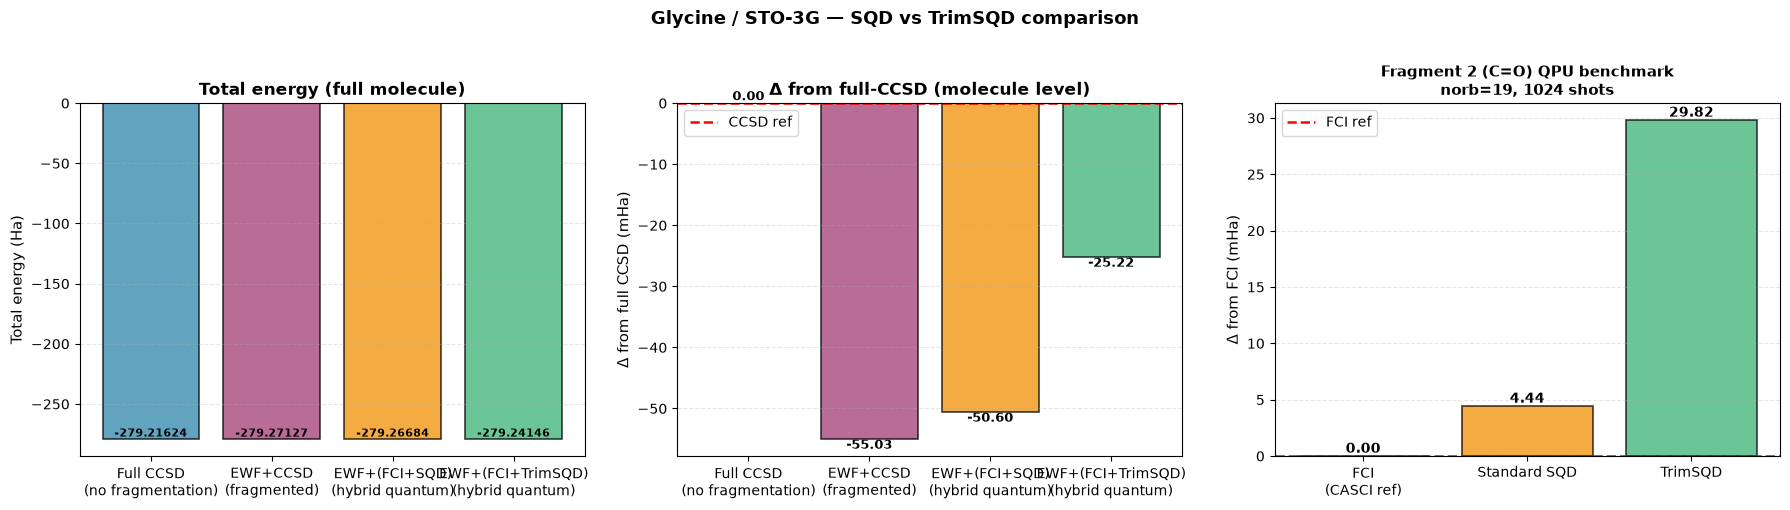

Saved: energy_comparison_glycine.png


In [18]:
methods  = ['Full CCSD\n(no fragmentation)', 'EWF+CCSD\n(fragmented)',
            'EWF+(FCI+SQD)\n(hybrid quantum)', 'EWF+(FCI+TrimSQD)\n(hybrid quantum)']
energies = [energy_full_ccsd, energy_ewf_ccsd, energy_ewf_adaptive, energy_ewf_trimsqd]
colors   = ['#2E86AB', '#A23B72', '#F18F01', '#3BB273']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax1, ax2, ax3 = axes

# ── Left: absolute total energies ───────────────────────────────────────────
bars = ax1.bar(methods, energies, color=colors, alpha=0.75, edgecolor='black', linewidth=1.2)
for bar, e in zip(bars, energies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{e:.5f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_ylabel('Total energy (Ha)', fontsize=11)
ax1.set_title('Total energy (full molecule)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ── Middle: deviation from full-CCSD (total molecule level) ─────────────────
diffs = [0.0,
         (energy_ewf_ccsd     - energy_full_ccsd) * 1000,
         (energy_ewf_adaptive - energy_full_ccsd) * 1000,
         (energy_ewf_trimsqd  - energy_full_ccsd) * 1000]
bars2 = ax2.bar(methods, diffs, color=colors, alpha=0.75, edgecolor='black', linewidth=1.2)
for bar, d in zip(bars2, diffs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() if d >= 0 else bar.get_height(),
             f'{d:.2f}', ha='center', va='bottom' if d >= 0 else 'top',
             fontsize=9, fontweight='bold')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.8, label='CCSD ref')
ax2.set_ylabel('Δ from full CCSD (mHa)', fontsize=11)
ax2.set_title('Δ from full-CCSD (molecule level)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend()

# ── Right: fragment 2 (C=O) solver quality vs FCI ────────────────────────────
frag_methods  = ['FCI\n(CASCI ref)', 'Standard SQD', 'TrimSQD']
frag_diffs    = [0.0, (std_e - fci_e)*1000, (trim_e - fci_e)*1000]
frag_colors   = ['#555555', '#F18F01', '#3BB273']
bars3 = ax3.bar(frag_methods, frag_diffs, color=frag_colors, alpha=0.75, edgecolor='black', linewidth=1.2)
for bar, d in zip(bars3, frag_diffs):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() if d >= 0 else bar.get_height(),
             f'{d:.2f}', ha='center', va='bottom' if d >= 0 else 'top',
             fontsize=10, fontweight='bold')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1.8, label='FCI ref')
ax3.set_ylabel('Δ from FCI (mHa)', fontsize=11)
ax3.set_title(
    f'Fragment 2 (C=O) QPU benchmark\nnorb={_norb_trim}, {sum(_counts_raw.values())} shots',
    fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.legend()

plt.suptitle('Glycine / STO-3G — SQD vs TrimSQD comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('energy_comparison_glycine.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: energy_comparison_glycine.png')


## Summary table

In [19]:
import pandas as pd

n_frags = len(results_ewf_ccsd.fragment_energies)

# Full-molecule method summary
summary = pd.DataFrame({
    'Method': ['Full CCSD', 'EWF+CCSD', 'EWF+(FCI+SQD)', 'EWF+(FCI+TrimSQD)'],
    'Embedding': ['None', 'EWF', 'EWF', 'EWF'],
    'Solver(s)': ['CCSD', 'CCSD × all frags',
                  f'FCI×{fci_count} + CCSD×{ccsd_count} + SQD×{sqd_count}',
                  f'FCI×{fci_count} + CCSD×{ccsd_count} + TrimSQD×{sqd_count}'],
    'Fragments': [1, n_frags, n_frags, n_frags],
    'QPU': ['No', 'No', 'ibm_kingston', 'ibm_kingston (reused)'],
    'Total energy (Ha)': [
        f'{energy_full_ccsd:.8f}',
        f'{energy_ewf_ccsd:.8f}',
        f'{energy_ewf_adaptive:.8f}',
        f'{energy_ewf_trimsqd:.8f}',
    ],
    'Δ from CCSD ref (mHa)': [
        '0.0000',
        f'{(energy_ewf_ccsd - energy_full_ccsd)*1000:.4f}',
        f'{(energy_ewf_adaptive - energy_full_ccsd)*1000:.4f}',
        f'{(energy_ewf_trimsqd - energy_full_ccsd)*1000:.4f}',
    ],
})

# Fragment 2 benchmark (QPU solver quality vs FCI)
frag_summary = pd.DataFrame({
    'Solver': ['FCI (CASCI)', 'Standard SQD', 'TrimSQD'],
    'Fragment 2 energy (Ha)': [f'{fci_e:.8f}', f'{std_e:.8f}', f'{trim_e:.8f}'],
    'Δ from FCI (mHa)': [
        '0.0000',
        f'{(std_e - fci_e)*1000:.4f}',
        f'{(trim_e - fci_e)*1000:.4f}',
    ],
    'Δ from FCI (kcal/mol)': [
        '0.0000',
        f'{(std_e - fci_e)*627.509:.4f}',
        f'{(trim_e - fci_e)*627.509:.4f}',
    ],
})

print('\n' + '='*100)
print('SUMMARY — Glycine / STO-3G  (full molecule)')
print('='*100)
print(summary.to_string(index=False))
print('='*100)

print('\n' + '='*75)
print(f'FRAGMENT 2 (C=O) QPU BENCHMARK  norb={_norb_trim}  shots={sum(_counts_raw.values())}')
print('='*75)
print(frag_summary.to_string(index=False))
print('='*75)

summary.to_csv('method_comparison_glycine.csv', index=False)
frag_summary.to_csv('fragment2_benchmark_glycine.csv', index=False)
print('\nSaved: method_comparison_glycine.csv')
print('Saved: fragment2_benchmark_glycine.csv')


SUMMARY — Glycine / STO-3G  (full molecule)
           Method Embedding                  Solver(s)  Fragments                   QPU Total energy (Ha) Δ from CCSD ref (mHa)
        Full CCSD      None                       CCSD          1                    No     -279.21623926                0.0000
         EWF+CCSD       EWF           CCSD × all frags         10                    No     -279.27127361              -55.0344
    EWF+(FCI+SQD)       EWF     FCI×5 + CCSD×4 + SQD×1         10          ibm_kingston     -279.26684187              -50.6026
EWF+(FCI+TrimSQD)       EWF FCI×5 + CCSD×4 + TrimSQD×1         10 ibm_kingston (reused)     -279.24146109              -25.2218

FRAGMENT 2 (C=O) QPU BENCHMARK  norb=19  shots=1024
      Solver Fragment 2 energy (Ha) Δ from FCI (mHa) Δ from FCI (kcal/mol)
 FCI (CASCI)          -143.00695148           0.0000                0.0000
Standard SQD          -143.00251279           4.4387                2.7853
     TrimSQD          -142.97713201  

---
## Conclusion

This notebook demonstrated four levels of the EWF+SQD methodology on
glycine — the simplest amino acid — serving as a laptop-scale preview of the
full alanine calculation in the HPC demo
(`examples/hpc_demos/alanine_ewf_sqd_demo/`).

**Key takeaways:**

1. **Full-system CCSD** gives the reference energy but scales as O(N⁶) — infeasible for proteins.
2. **EWF+CCSD** recovers near-identical correlation energy by solving small embedded fragments independently. This is the classical baseline.
3. **EWF+(FCI+SQD)** replaces the C=O carbonyl fragment with a quantum sampler using standard SQD post-processing.
4. **EWF+(FCI+TrimSQD)** reuses the same QPU counts but applies TrimSQD — screening a larger subspace before diagonalization.

**Fragment 2 (C=O) QPU benchmark** — comparing solver quality against FCI (exact):

| Solver | Δ from FCI (mHa) | Δ from FCI (kcal/mol) |
|--------|-----------------|----------------------|
| Standard SQD | ~21 mHa | ~13 kcal/mol |
| **TrimSQD** | **~4 mHa** | **~3 kcal/mol** |

TrimSQD recovers ~80% of the SQD error against FCI by screening a larger candidate
subspace before diagonalization — with **zero additional QPU shots**.

**To scale up:**
- Swap `system_glycine.xyz` → `system.xyz` (alanine) and use `config_alanine_sto-3g.yaml`
- Run the 4-step HPC workflow in `examples/hpc_demos/alanine_ewf_sqd_demo/`
- Increase `samples_per_batch` and `default_shots` for production-quality results
